In [1]:
import sys
sys.path.append('..')
import xarray as xr
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import colorcet as cc
from scipy.stats import linregress
from src.inversion_scripts.utils import plot_field, sum_total_emissions
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

In [2]:
state_vector_filepath = "/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2022_annual/StateVector.nc"

state_vector = xr.open_dataset(state_vector_filepath)
state_vector_labels = state_vector["StateVector"]

# Identify the last element of the region of interest
last_ROI_element = int(
    np.nanmax(state_vector_labels.values)
)

# Define mask for region of interest
mask = state_vector_labels <= last_ROI_element

In [3]:
mask_eastafrica = xr.open_dataset("../shapefiles/masks/east_africa.nc")
mask_eastafrica = mask_eastafrica.rename({"__xarray_dataarray_variable__": "Mask"})
mask_eastafrica = mask_eastafrica["Mask"]
mask_eastafrica = mask_eastafrica.fillna(0).astype(float)

In [3]:
def plot_field(
    ax,
    field,
    cmap,
    plot_type="pcolormesh",
    lon_bounds=None,
    lat_bounds=None,
    levels=None,
    vmin=None,
    vmax=None,
    title=None,
    point_sources=None,
    cbar_label=None,
    mask=None,
    only_ROI=False,
    state_vector_labels=None,
    last_ROI_element=None,
    is_regional=True,
    save_path=None,
    clean_title=None,
):
    """
    Function to plot inversion results.

    Arguments
        ax         : matplotlib axis object
        field      : xarray dataarray
        cmap       : colormap to use, e.g. 'viridis'
        plot_type  : 'pcolormesh' or 'imshow'
        lon_bounds : [lon_min, lon_max]
        lat_bounds : [lat_min, lat_max]
        levels     : number of colormap levels (None for continuous)
        vmin       : colorbar lower bound
        vmax       : colorbar upper bound
        title      : plot title
        point_sources: plot given point sources on map
        cbar_label : colorbar label
        mask       : mask for region of interest, boolean dataarray
        only_ROI   : zero out data outside the region of interest, true or false
        save_path  : path to save the plot
        clean_title: title without special characters
    """

    # Select map features
    if is_regional:
        oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
        lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
        states_provinces_50m = cartopy.feature.NaturalEarthFeature(
            "cultural", "admin_1_states_provinces_lines", "50m"
        )
        ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.4)
        ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.5)
        # ax.add_feature(lakes_50m, facecolor="none", edgecolor="black")
        # ax.add_feature(states_provinces_50m, facecolor="none", edgecolor="black")
    else:
        ax.coastlines(resolution="110m")

    # Show only ROI values?
    if only_ROI:
        field = field.where((state_vector_labels <= last_ROI_element))

    # Plot
    if plot_type == "pcolormesh":
        field.plot.pcolormesh(
            cmap=cmap,
            levels=levels,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cbar_kwargs={"label": cbar_label, "fraction": 0.02, "pad": 0.04}
        )
    elif plot_type == "imshow":
        field.plot.imshow(
            cmap=cmap,
            levels=levels,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cbar_kwargs={"label": cbar_label, "fraction": 0.041, "pad": 0.04},
        )
    else:
        raise ValueError('plot_type must be "pcolormesh" or "imshow"')

    # Zoom on ROI?
    if lon_bounds and lat_bounds:
        extent = [lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]]
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Show boundary of ROI?
    if mask is not None:
        # mask.plot.contour(levels=1, colors="k", linewidths=4, ax=ax)
        mask_eastafrica.plot.contour(
            levels=[0.5],                       # contour between 0 and 1
            transform=ccrs.PlateCarree(),       # tells Cartopy it's lon/lat data
            colors="k",
            linewidths=2,
            ax=ax
        )

    # Remove duplicated axis labels
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0) # draw_labels=True for lat/lon labels
    gl.right_labels = False
    gl.top_labels = False

    # Title
    if title:
        ax.set_title(title)

    # Marks any specified high-resolution coordinates on the preview observation density map
    if point_sources:
        for coord in point_sources:
            ax.plot(coord[1], coord[0], marker="x", markeredgecolor="black")
        point = Line2D(
            [0],
            [0],
            label="point source",
            marker="x",
            markersize=10,
            markeredgecolor="black",
            markerfacecolor="k",
            linestyle="",
        )
        ax.legend(handles=[point])

In [4]:
invdir = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe"
years = [2019, 2020, 2021, 2022, 2023, 2024]
emissions_list = []
areas = []

for year in years:
    if year == 2019:
        posterior_ds = xr.load_dataset(f"{invdir}/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc")
    else:
        posterior_ds = xr.load_dataset(f"{invdir}/Global_{year}_annual/inversion/posterior_ds.nc")
    posterior = posterior_ds["EmisCH4_Total"]
    area = posterior_ds["AREA"]
    emissions_Tg_a = posterior * area * 86400 * 365 * 1e-9  # convert to Tg/y
    # emissions_Tg_a = sum_total_emissions(posterior, area, mask)  # convert to Tg/y
    emissions_list.append(emissions_Tg_a)

# stack emissions along time
emissions = xr.concat(emissions_list, dim="time")
emissions = emissions.assign_coords(time=np.array(years))

def linear_trend(y):
    """
    Compute linear regression slope over time for each grid cell.
    """
    x = np.array(years)

    slope, _, _, p_value, _ = stats.linregress(x, y)
    return slope if p_value < 0.05 else np.nan # trend in Tg a^-2 (only if significant)

# Apply linear regression function to each grid cell
trends = xr.apply_ufunc(
    linear_trend,
    emissions,
    input_core_dims=[["time"]],
    vectorize=True
)

nan


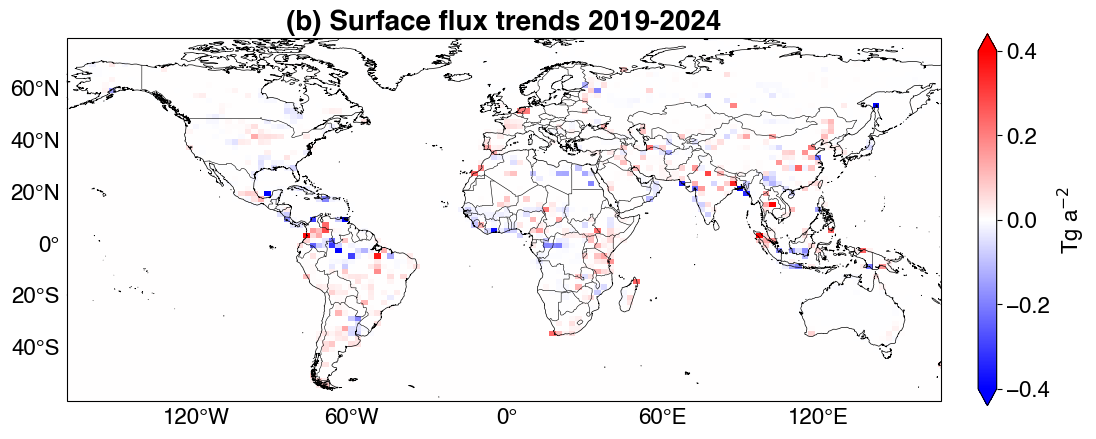

In [ ]:
# Load state vector
state_vector = xr.load_dataset(f"{invdir}/Global_2020_annual/StateVector.nc")
state_vector_labels = state_vector["StateVector"]
last_ROI_element = int(
    np.nanmax(state_vector_labels.values) - 0
)
mask = state_vector_labels <= last_ROI_element

# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_save_path = "regional_trend_plots"
print(trends.sel(lat=54, lon=-97.5, method="nearest").item())

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_significant = trends.where(~np.isnan(trends), 0)

# make background color slightly grey to match the 0's
norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)
central_color = cmap(norm(0))
ax.set_facecolor(central_color)

plot_field(
    ax,
    trends_significant,
    cmap=cmap,
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-0.4,
    vmax=0.4,
    title=f"Surface flux trends {years[0]}-{years[-1]}",
    cbar_label="Tg a$^{-2}$",
    only_ROI=True,
    mask=None,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True
)
plt.title(f"(b) Surface flux trends {years[0]}-{years[-1]}", fontproperties=title_font, fontsize=20)
plt.savefig("figures/3b.png", dpi=600, bbox_inches="tight")

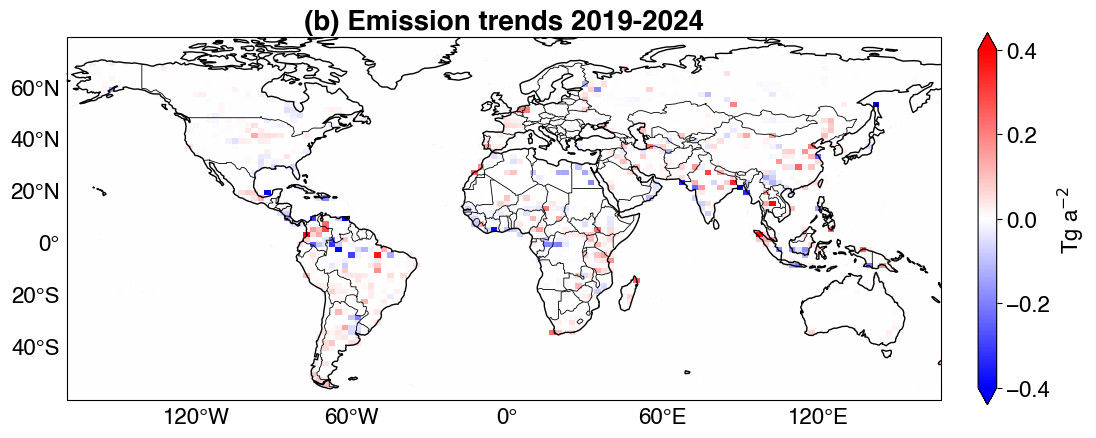

In [9]:
# Load state vector
state_vector = xr.load_dataset(f"{invdir}/Global_2020_annual/StateVector.nc")
state_vector_labels = state_vector["StateVector"]
last_ROI_element = int(
    np.nanmax(state_vector_labels.values) - 0
)
mask = state_vector_labels <= last_ROI_element

# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_significant = trends.where(~np.isnan(trends), 0)

# make background color slightly grey to match the 0's
norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)
central_color = cmap(norm(0))
ax.set_facecolor(central_color)

trends_significant.plot.pcolormesh(ax=ax,cmap=cmap, vmin=-0.4, vmax=0.4, cbar_kwargs={"label": "Tg a$^{-2}$", "fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0)
gl.right_labels = False
gl.top_labels = False

plt.title(f"(b) Emission trends {years[0]}-{years[-1]}", fontproperties=title_font, fontsize=20)
plt.savefig("figures/3b.png", dpi=1200, bbox_inches="tight")

0.195827375643363
0.20898456396885598


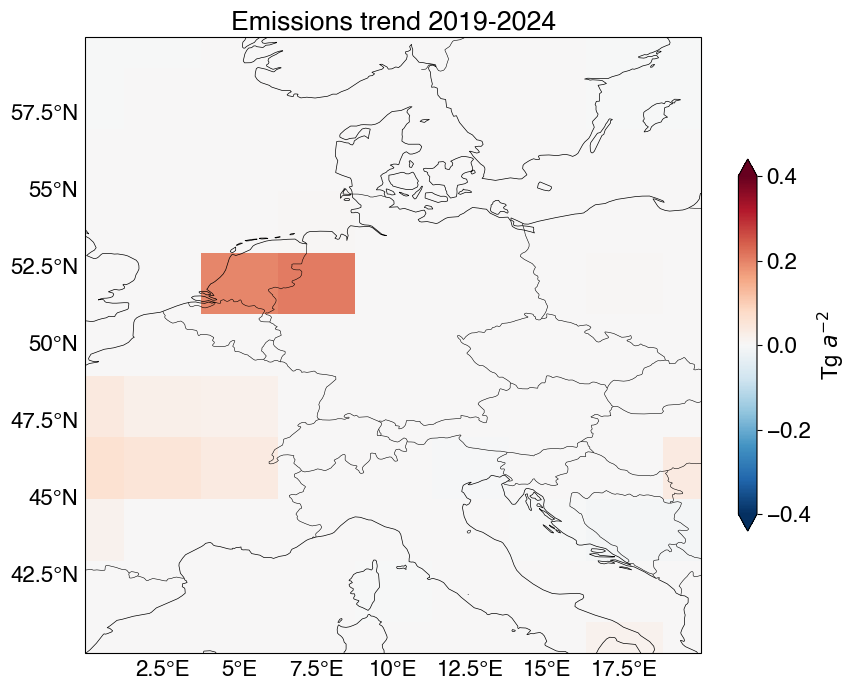

In [13]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

print(trends_significant.sel(lat=52, lon=5, method="nearest").item())
print(trends_significant.sel(lat=52, lon=7.5, method="nearest").item())

plot_field(
    ax,
    trends_significant,
    cmap='RdBu_r',
    lon_bounds=[0, 20],
    lat_bounds=[40, 60],
    vmin=-0.4,
    vmax=0.4,
    title=f"Emissions trend {years[0]}-{years[-1]}",
    cbar_label="Tg $a^{-2}$",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True
)

0.3953601943933936
0.5566180598049913
-1.0452088755596816


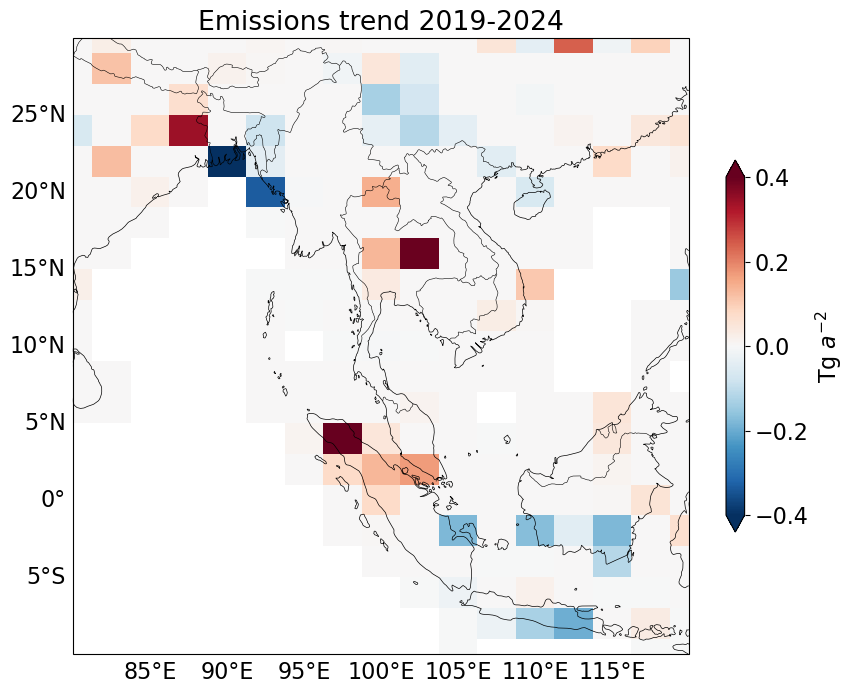

In [5]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

print(trends_significant.sel(lat=16, lon=102.5, method="nearest").item())
print(trends_significant.sel(lat=4, lon=97.5, method="nearest").item())
print(trends_significant.sel(lat=22, lon=90, method="nearest").item())

plot_field(
    ax,
    trends_significant,
    cmap='RdBu_r',
    lon_bounds=[80, 120],
    lat_bounds=[-10, 30],
    vmin=-0.4,
    vmax=0.4,
    title=f"Emissions trend {years[0]}-{years[-1]}",
    cbar_label="Tg $a^{-2}$",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True
)

## Calculate relative trend

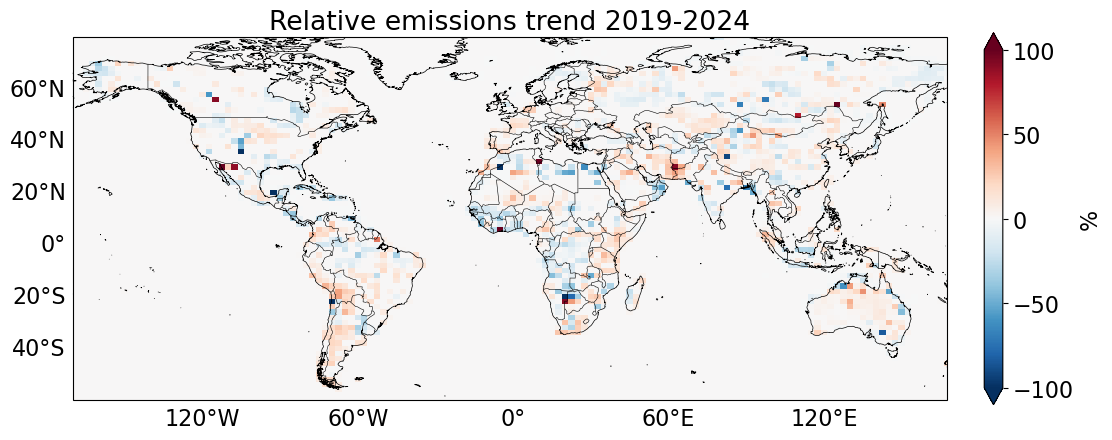

In [5]:
mean_emissions = emissions.mean(dim='time')

relative_trends = (trends / mean_emissions)*100

relative_trends_significant = relative_trends.where(~np.isnan(relative_trends), 0)

fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad('white', alpha=0)

# make background color slightly grey to match the 0's
norm = mcolors.Normalize(vmin=-0.4, vmax=0.4)
central_color = cmap(norm(0))
ax.set_facecolor(central_color)

plot_field(
    ax,
    relative_trends_significant,
    cmap=cmap,
    lon_bounds=[-170, 167.5],
    lat_bounds=[-60, 80],
    vmin=-100,
    vmax=100,
    title=f"Relative emissions trend {years[0]}-{years[-1]}",
    cbar_label="%",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
    is_regional=True
)

## More detailed analysis

In [62]:
print(trends.sel(lat=-4, lon=-50, method="nearest").item())
print(trends.sel(lat=-4, lon=-60, method="nearest").item())
print(trends.sel(lat=-18, lon=-55, method="nearest").item())
print(trends.sel(lat=10, lon=-62.5, method="nearest").item())
print(trends.sel(lat=10, lon=-75, method="nearest").item())
print(trends.sel(lat=-34, lon=17.5, method="nearest").item())

0.5244450749146031
-0.3555768224046732
0.38075205122936734
-0.5703884828027602
-0.33380828620194825
0.33599888635597397


In [3]:
invdir = f"/n/holylfs06/LABS/jacob_lab2/Lab/mhe"
years = [2019, 2020, 2021, 2022, 2023, 2024]
emissions_og_list = []
emissions_rice_list = []
emissions_waste_list = []
emissions_livestock_list = []
emissions_wetlands_list = []
areas = []

for year in years:
    if year == 2019:
        posterior_ds = xr.load_dataset(f"{invdir}/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc")
    else:
        posterior_ds = xr.load_dataset(f"{invdir}/Global_{year}_annual/inversion/posterior_ds.nc")
    posterior_og = posterior_ds["EmisCH4_Oil"] + posterior_ds["EmisCH4_Gas"]
    posterior_rice = posterior_ds["EmisCH4_Rice"]
    posterior_waste = posterior_ds["EmisCH4_Wastewater"] + posterior_ds["EmisCH4_Landfills"]
    posterior_livestock = posterior_ds["EmisCH4_Livestock"]
    posterior_wetlands = posterior_ds["EmisCH4_Wetlands"]

    area = posterior_ds["AREA"]
    emissions_og_Tg_a = posterior_og * area * 86400 * 365 * 1e-9  # convert to Tg/y
    emissions_rice_Tg_a = posterior_rice * area * 86400 * 365 * 1e-9  # convert to Tg/y
    emissions_waste_Tg_a = posterior_waste * area * 86400 * 365 * 1e-9  # convert to Tg/y
    emissions_livestock_Tg_a = posterior_livestock * area * 86400 * 365 * 1e-9  # convert to Tg/y
    emissions_wetlands_Tg_a = posterior_wetlands * area * 86400 * 365 * 1e-9  # convert to Tg/y

    emissions_og_list.append(emissions_og_Tg_a)
    emissions_rice_list.append(emissions_rice_Tg_a)
    emissions_waste_list.append(emissions_waste_Tg_a)
    emissions_livestock_list.append(emissions_livestock_Tg_a)
    emissions_wetlands_list.append(emissions_wetlands_Tg_a)

# stack emissions along time
emissions_og = xr.concat(emissions_og_list, dim="time")
emissions_og = emissions_og.assign_coords(time=np.array(years))

emissions_rice = xr.concat(emissions_rice_list, dim="time")
emissions_rice = emissions_rice.assign_coords(time=np.array(years))

emissions_waste = xr.concat(emissions_waste_list, dim="time")
emissions_waste = emissions_waste.assign_coords(time=np.array(years))

emissions_livestock = xr.concat(emissions_livestock_list, dim="time")
emissions_livestock = emissions_livestock.assign_coords(time=np.array(years))

emissions_wetlands = xr.concat(emissions_wetlands_list, dim="time")
emissions_wetlands = emissions_wetlands.assign_coords(time=np.array(years))

def linear_trend(y):
    """
    Compute linear regression slope over time for each grid cell.
    """
    x = np.array(years)

    slope, _, _, p_value, _ = stats.linregress(x, y)
    return slope if p_value < 0.05 else np.nan # trend in Tg a^-2 (only if significant)

# Apply linear regression function to each grid cell
trends_og = xr.apply_ufunc(
    linear_trend,
    emissions_og,
    input_core_dims=[["time"]],
    vectorize=True
)

trends_rice = xr.apply_ufunc(
    linear_trend,
    emissions_rice,
    input_core_dims=[["time"]],
    vectorize=True
)

trends_waste = xr.apply_ufunc(
    linear_trend,
    emissions_waste,
    input_core_dims=[["time"]],
    vectorize=True
)

trends_livestock = xr.apply_ufunc(
    linear_trend,
    emissions_livestock,
    input_core_dims=[["time"]],
    vectorize=True
)

trends_wetlands = xr.apply_ufunc(
    linear_trend,
    emissions_wetlands,
    input_core_dims=[["time"]],
    vectorize=True
)

Text(0.5, 1.0, 'Oil/gas')

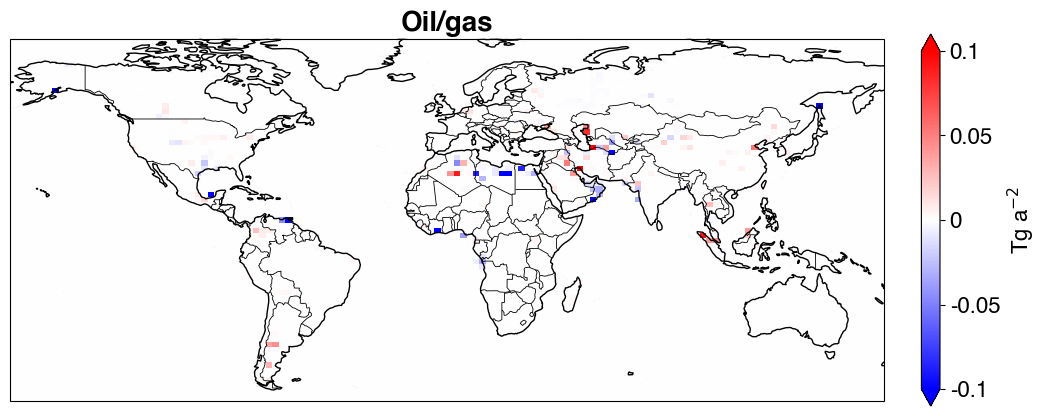

In [17]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_og_significant = trends_og.where(~np.isnan(trends_og), 0)

trends_og_significant.plot.pcolormesh(ax=ax,cmap=cmap, vmin=-0.1, vmax=0.1, extend='both', cbar_kwargs={"label": "Tg a$^{-2}$","format": "%g","fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

plt.title(f"Oil/gas", fontproperties=title_font, fontsize=20)
# plt.savefig("figures/3b.png", dpi=1200, bbox_inches="tight")

Text(0.5, 1.0, 'Rice')

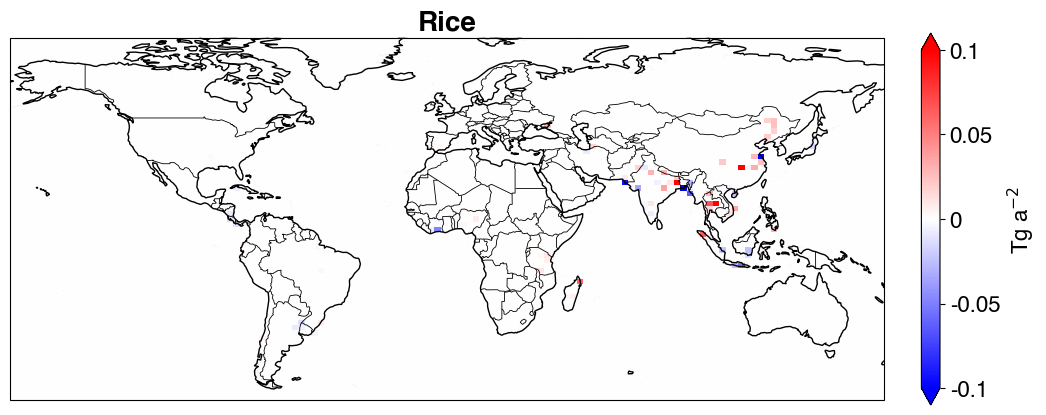

In [18]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_rice_significant = trends_rice.where(~np.isnan(trends_rice), 0)

trends_rice_significant.plot.pcolormesh(ax=ax,cmap=cmap, vmin=-0.1, vmax=0.1, extend='both', cbar_kwargs={"label": "Tg a$^{-2}$", "format": "%g","fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

plt.title(f"Rice", fontproperties=title_font, fontsize=20)

Text(0.5, 1.0, 'Waste')

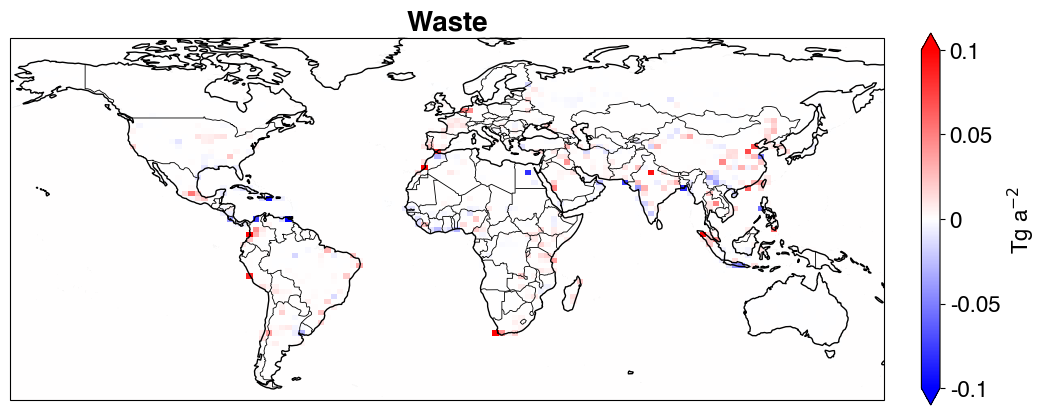

In [19]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_waste_significant = trends_waste.where(~np.isnan(trends_waste), 0)

trends_waste_significant.plot.pcolormesh(ax=ax,cmap=cmap, vmin=-0.1, vmax=0.1, extend='both', cbar_kwargs={"label": "Tg a$^{-2}$", "format": "%g","fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

plt.title(f"Waste", fontproperties=title_font, fontsize=20)

Text(0.5, 1.0, 'Livestock')

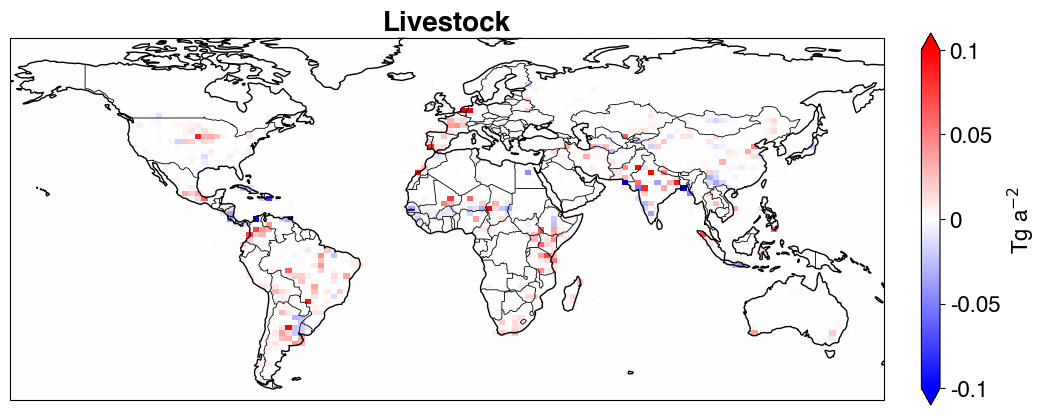

In [20]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_livestock_significant = trends_livestock.where(~np.isnan(trends_livestock), 0)

trends_livestock_significant.plot.pcolormesh(ax=ax,cmap=cmap, vmin=-0.1, vmax=0.1, extend='both', cbar_kwargs={"label": "Tg a$^{-2}$", "format": "%g","fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

plt.title(f"Livestock", fontproperties=title_font, fontsize=20)

Text(0.5, 1.0, 'Wetlands')

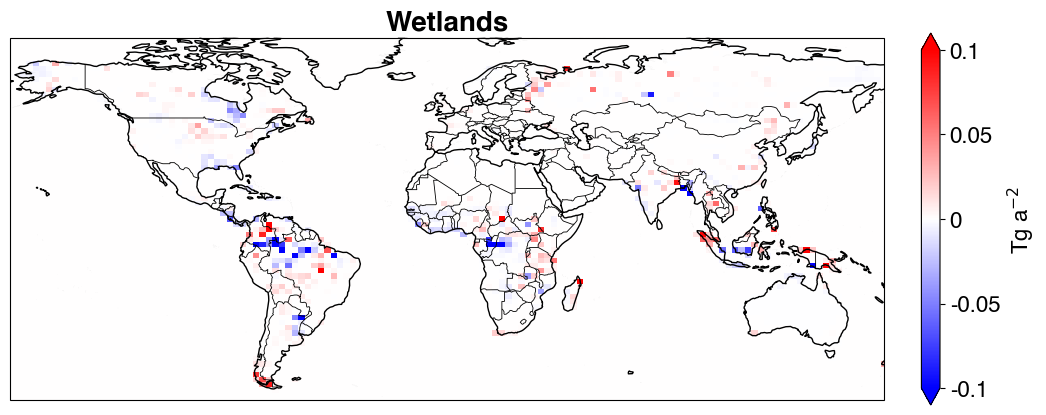

In [4]:
# Plot posterior emissions
fig = plt.figure(figsize=(12, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# set the NaNs to white
cmap = plt.get_cmap('bwr').copy()
cmap.set_bad('white', alpha=0)

trends_wetlands_significant = trends_wetlands.where(~np.isnan(trends_wetlands), 0)

trends_wetlands_significant.plot.pcolormesh(ax=ax,cmap=cmap, vmin=-0.1, vmax=0.1, extend='both', cbar_kwargs={"label": "Tg a$^{-2}$", "format": "%g","fraction": 0.02, "pad": 0.04}, transform=ccrs.PlateCarree())

extent = [-170, 167.5, -60, 80]
ax.set_extent(extent, crs=ccrs.PlateCarree())
oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
states_provinces_50m = cartopy.feature.NaturalEarthFeature(
    "cultural", "admin_1_states_provinces_lines", "50m"
)
ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
ax.coastlines(color='black')

plt.title(f"Wetlands", fontproperties=title_font, fontsize=20)

In [8]:
lat_bounds_sudd = [5, 10]
lon_bounds_sudd = [28, 34.5]

# select grid cells only within lat and lon bounds in posterior
posterior_subset = trends.where((trends.lat > lat_bounds_sudd[0]) 
                            & (trends.lat < lat_bounds_sudd[1]) 
                            & (trends.lon > lon_bounds_sudd[0]) 
                            & (trends.lon < lon_bounds_sudd[1]), drop=True)

print(posterior_subset.sum().values)

-0.048466140469669704
